# 전력 수요 이상탐지 — 전체 과정

전국 시간별 전력수요 데이터에서 이상을 찾아내고, **그 이상이 진짜 문제인지 아닌지 판별**하는 과정입니다.

파이썬이나 판다스를 처음 봐도 따라올 수 있도록 각 단계에 설명을 붙였습니다.

## 이 노트북에서 답하는 질문

1. 전력수요 데이터에서 "이상"을 어떻게 정의하는가 → 2장
2. 얼마나 벗어나야 이상인가 (임계값은 어떻게 정하는가) → 3장
3. 걸린 것들이 진짜 이상인가 → 4장
4. 아니라면 원인이 무엇인가 → 5\~6장
5. 어디까지가 확인이고 어디부터가 추정인가 → 7장

## 데이터

| | |
|---|---|
| 이름 | 한국전력거래소 시간별 전국 전력수요량 |
| 기간 | 2025년 1월 1일 ~ 12월 31일 |
| 크기 | 8,760행 (365일 × 24시간) |
| 단위 | MW (순간 전력). 시간당 누적은 MWh |
| 출처 | data.go.kr/data/15065266/fileData.do |

---
# 0장 · 준비

## 왜 이 셀이 필요한가

Colab은 **세션이 끊기면 설치한 것이 전부 사라집니다.** 한글 폰트도 마찬가지라서 새로 열 때마다 다시 설치해야 합니다.

`fm.fontManager.addfont(...)`로 직접 등록하는 이유는, 설치만 하고 런타임을 재시작해도 matplotlib이 폰트를 못 잡는 경우가 있기 때문입니다. 그래프 한글이 □□□로 나오면 이 셀부터 다시 실행하세요.

In [1]:
# 라이브러리 불러오기
# import A as B → "A를 가져오되 B라는 짧은 이름으로 부르겠다"
import pandas as pd          # 표(엑셀 같은 것)를 다루는 도구
import numpy as np           # 수치 계산 도구
import matplotlib.pyplot as plt          # 그래프 그리는 도구
import matplotlib.font_manager as fm     # 폰트 관리

# 구글 드라이브 연결 (실행하면 권한 승인 창이 뜬다)
from google.colab import drive
drive.mount('/content/drive')

# 한글 폰트 설치 → 등록 → 적용
!apt-get -qq install -y fonts-nanum > /dev/null
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 이걸 안 하면 그래프의 마이너스 부호가 깨진다
plt.rcParams['figure.dpi'] = 110             # 해상도

print('준비 완료')

Mounted at /content/drive
준비 완료


---
# 1장 · 데이터 불러오기와 형태 바꾸기

## 문제 — 원본은 우리가 원하는 모양이 아니다

내려받은 CSV는 **가로형**입니다.

| 날짜 | 1시 | 2시 | 3시 | … | 24시 |
|---|---|---|---|---|---|
| 2025-01-01 | 62256 | 59663 | 57880 | … | 61200 |

한 행에 하루가 통째로 들어 있습니다. 이상탐지를 하려면 **한 행에 한 시간**인 세로형이 필요합니다.

| 시각 | 사용량 |
|---|---|
| 2025-01-01 00:00 | 62256 |
| 2025-01-01 01:00 | 59663 |

## 세 가지 함정

**① 인코딩** — 한국 공공데이터는 UTF-8이 아니라 `cp949`인 경우가 많습니다. 그냥 읽으면 한글이 깨지거나 에러가 납니다.

**② melt** — 가로를 세로로 눕히는 함수입니다. `id_vars`는 그대로 둘 열, `value_vars`는 눕힐 열입니다.

**③ "1시"는 0시다** — 전력거래소 표기에서 "1시"는 00:00~01:00 구간을 뜻합니다. 그대로 쓰면 데이터 전체가 한 시간씩 밀립니다.

In [2]:
CSV = '/content/drive/MyDrive/한국전력거래소_시간별 전국 전력수요량_20251231.csv'

raw = pd.read_csv(CSV, encoding='cp949')   # ① cp949로 읽는다
raw = raw.dropna(how='all')                # 전부 빈 행 제거 (how='all' = 모든 칸이 비었을 때만)
print('원본 모양:', raw.shape)              # (행, 열)
print('열 이름 앞 5개:', raw.columns.tolist()[:5])
raw.head(2)

원본 모양: (365, 25)
열 이름 앞 5개: ['날짜', '1시', '2시', '3시', '4시']


,날짜,1시,2시,3시,4시,5시,6시,7시,8시,9시,...,15시,16시,17시,18시,19시,20시,21시,22시,23시,24시
0,2025-01-01,62256.0,59663.0,57880.0,57098.0,56966.0,57442.0,58338.0,58868.0,58090.0,...,49914.0,53489.0,58061.0,62545.0,64403.0,64403.0,63653.0,62722.0,62249.0,61871.0
1,2025-01-02,59219.0,57092.0,55931.0,55597.0,56374.0,58691.0,63081.0,70103.0,77832.0,...,70016.0,73169.0,76318.0,77503.0,76379.0,74902.0,72276.0,69663.0,69473.0,68787.0


In [3]:
# ② 가로 → 세로 (melt)
시간컬럼 = [c for c in raw.columns if str(c).endswith('시')]   # '1시'~'24시' 열만 골라낸다
print('시간 컬럼 개수:', len(시간컬럼), '→', 시간컬럼[:3], '...')

long = raw.melt(
    id_vars='날짜',           # 그대로 유지할 열
    value_vars=시간컬럼,      # 아래로 눕힐 열들
    var_name='시간',          # 눕힌 열 이름이 들어갈 새 컬럼
    value_name='사용량'       # 값이 들어갈 새 컬럼
)

# ③ "1시" → 0, "2시" → 1 … "24시" → 23
long['hour'] = long['시간'].str.replace('시','', regex=False).astype(int) - 1

# 날짜 + 시간 = 하나의 타임스탬프
long['시각'] = pd.to_datetime(long['날짜']) + pd.to_timedelta(long['hour'], unit='h')

df = long[['시각','사용량']].dropna().sort_values('시각').reset_index(drop=True)
print('\n변환 후:', df.shape)
df.head(3)

시간 컬럼 개수: 24 → ['1시', '2시', '3시'] ...

변환 후: (8760, 2)


,시각,사용량
0,2025-01-01 00:00:00,62256.0
1,2025-01-01 01:00:00,59663.0
2,2025-01-01 02:00:00,57880.0


In [4]:
# 데이터가 제대로 들어왔는지 확인 — 이 단계를 건너뛰면 나중에 전부 다시 해야 한다
print(f'기간: {df["시각"].min():%Y-%m-%d %H시} ~ {df["시각"].max():%Y-%m-%d %H시}')
print(f'행 수: {len(df)}  (365일 × 24시간 = 8760)')
print(f'결측: {df.isna().sum().sum()}건')
print()
print(f'평균  {df["사용량"].mean():>9,.0f} MW')
print(f'최소  {df["사용량"].min():>9,.0f} MW')
print(f'최대  {df["사용량"].max():>9,.0f} MW')
print(f'부하율 {df["사용량"].mean()/df["사용량"].max()*100:>8.1f} %   (평균÷최대. 낮을수록 피크가 뾰족하다)')
print()
print(f'※ 최대 {df["사용량"].max():,.0f}MW는 실제 국내 계통의 여름 피크 규모와 맞는다.')
print('   숫자가 현실과 맞는지 확인하는 것이 단위 오류를 잡는 가장 빠른 방법이다.')

기간: 2025-01-01 00시 ~ 2025-12-31 23시
행 수: 8760  (365일 × 24시간 = 8760)
결측: 0건

평균     64,503 MW
최소     35,811 MW
최대     95,951 MW
부하율     67.2 %   (평균÷최대. 낮을수록 피크가 뾰족하다)

※ 최대 95,951MW는 실제 국내 계통의 여름 피크 규모와 맞는다.
   숫자가 현실과 맞는지 확인하는 것이 단위 오류를 잡는 가장 빠른 방법이다.


### 여기서 배운 것

- `encoding='cp949'` — 한국 공공데이터의 기본값이라고 생각해도 된다
- `melt()` — 가로형을 세로형으로. 시계열 분석의 거의 모든 전처리에 등장한다
- **단위 검증** — 계산 결과가 현실의 규모와 맞는지 확인. 이 프로젝트에서 실제로 kW로 잘못 표기했다가 이 방법으로 발견했다

---
# 2장 · "이상"을 어떻게 정의하는가

## 왜 단순히 "수요가 낮으면 이상"이 아닌가

새벽 3시는 원래 수요가 낮습니다. 여름은 원래 높습니다. **절대값으로는 이상을 못 찾습니다.**

## 이동평균 기준선

"지금 시점 전후 1주일의 평균"을 그 시기의 **평상시 수요**로 봅니다. 실제 값이 여기서 얼마나 벗어났는지를 봅니다.

```
편차 = 실제값 - 기준선
z    = 편차 ÷ 표준편차     (몇 σ 벗어났는가)
```

## 설정값 두 개의 이유

**`window=168`** — 168시간 = 7일. 요일 주기를 통째로 담아야 평일/주말 차이가 기준선 자체에 섞이지 않습니다. 24시간으로 잡으면 일요일 기준선이 일요일 수준으로 내려가서 일요일 이상을 못 잡습니다.

**`center=True`** — 앞뒤를 같이 봅니다. `False`면 과거만 보므로 기준선이 뒤로 밀려서, 이상이 실제보다 늦게 탐지됩니다.

In [5]:
d = df.copy()   # 원본 df는 그대로 두고 사본에서 작업 (실수해도 되돌리기 쉽다)

WINDOW = 168   # 7일 × 24시간

# rolling = 창을 옆으로 밀면서 계산. min_periods = 최소 이만큼 값이 있어야 계산한다
d['기준선']   = d['사용량'].rolling(WINDOW, center=True, min_periods=WINDOW//2).mean()
d['표준편차'] = d['사용량'].rolling(WINDOW, center=True, min_periods=WINDOW//2).std()

d['편차'] = d['사용량'] - d['기준선']     # MW 단위 — 규모를 직관적으로 볼 때
d['z']    = d['편차'] / d['표준편차']     # σ 단위 — 시기별 변동성을 보정해 비교할 때

# .dt 접근자로 시간에서 정보를 뽑아낸다
d['월']   = d['시각'].dt.month
d['요일'] = d['시각'].dt.dayofweek        # 0=월요일 … 6=일요일
d['시']   = d['시각'].dt.hour
d['날짜'] = d['시각'].dt.date

print('z 결측:', d['z'].isna().sum(), '건')
d[['시각','사용량','기준선','편차','z']].head(3).round({'사용량':1,'기준선':1,'편차':1,'z':2})

z 결측: 0 건


,시각,사용량,기준선,편차,z
0,2025-01-01 00:00:00,62256.0,65236.4,-2980.4,-0.37
1,2025-01-01 01:00:00,59663.0,65115.7,-5452.7,-0.67
2,2025-01-01 02:00:00,57880.0,65014.8,-7134.8,-0.88


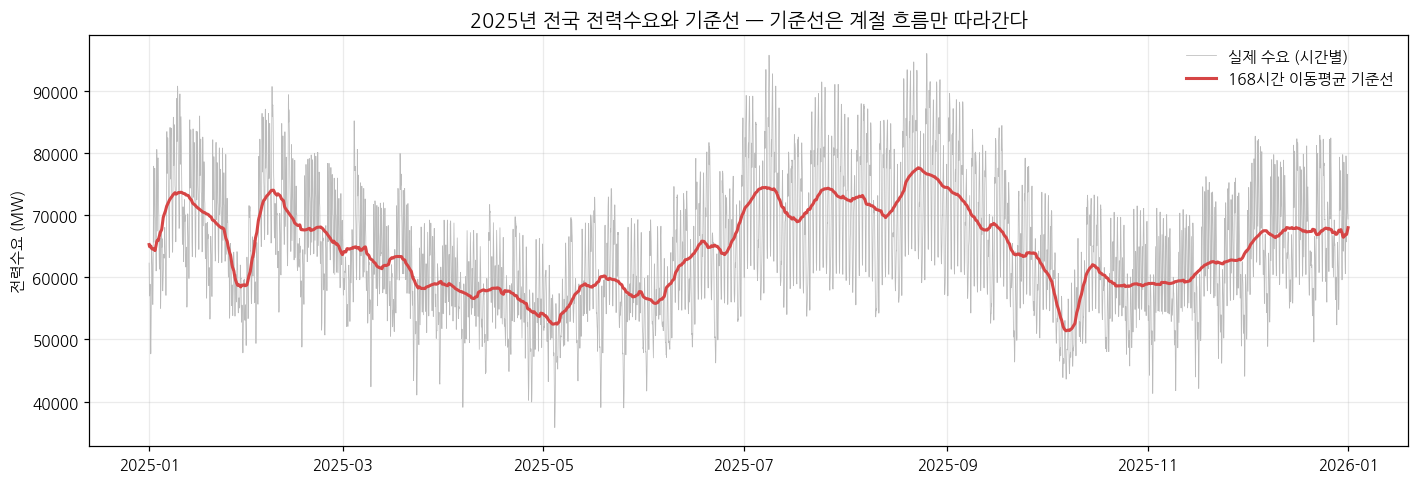

회색의 두꺼운 띠 = 하루 안의 오르내림. 빨간선은 그 중심을 따라간다.
이상탐지는 "빨간선에서 회색이 얼마나 튀었는가"를 보는 작업이다.


In [6]:
# 실제값과 기준선을 겹쳐 그려서 '기준선'이 무엇인지 눈으로 본다
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(d['시각'], d['사용량'], color='#BBB', lw=0.5, label='실제 수요 (시간별)')
ax.plot(d['시각'], d['기준선'], color='#D64545', lw=2, label='168시간 이동평균 기준선')
ax.set_ylabel('전력수요 (MW)')
ax.set_title('2025년 전국 전력수요와 기준선 — 기준선은 계절 흐름만 따라간다', fontsize=13)
ax.legend(frameon=False); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

print('회색의 두꺼운 띠 = 하루 안의 오르내림. 빨간선은 그 중심을 따라간다.')
print('이상탐지는 "빨간선에서 회색이 얼마나 튀었는가"를 보는 작업이다.')

---
# 3장 · 임계값은 얼마로 할 것인가

## 정답이 없는 문제

몇 σ부터 이상으로 볼지는 **데이터가 정해주지 않습니다.** 실무자가 정합니다.

- 너무 낮으면 → 정상 변동까지 다 걸려서 알람이 쏟아지고, 결국 아무도 안 봅니다
- 너무 높으면 → 진짜 이상을 놓칩니다

그래서 여러 값을 넣어보고 **탐지 건수가 어떻게 변하는지**를 근거로 정합니다.

In [7]:
결과 = []
for K in [2.0, 2.5, 3.0, 3.5]:
    n = (d['z'].abs() >= K).sum()        # abs() = 절댓값. 상승·하강 양쪽 다 본다
    결과.append({'임계값': f'{K}σ', '탐지 건수': n, '전체 대비(%)': round(n/len(d)*100, 2)})

표 = pd.DataFrame(결과)
print(표.to_string(index=False))
print()
# 설명 문장의 숫자는 계산 결과에서 끌어온다.
# 손으로 타이핑하면 데이터가 바뀌어도 문장이 안 바뀌고, 에러도 안 난다.
n = {r['임계값']: r['탐지 건수'] for _, r in 표.iterrows()}
print(f'2.0σ → {n["2.0σ"]}건. 이틀에 하나꼴이라 운영자가 감당 못 한다.')
print(f'3.0σ → {n["3.0σ"]}건.  놓치는 게 더 많을 위험.')
print(f'2.5σ → {n["2.5σ"]}건. 열흘에 하나꼴. 사람이 실제로 들여다볼 수 있는 양.')
print()
print('→ 2.5σ 채택')

 임계값  탐지 건수  전체 대비(%)
2.0σ    169      1.93
2.5σ     34      0.39
3.0σ      4      0.05
3.5σ      0      0.00

2.0σ → 169건. 이틀에 하나꼴이라 운영자가 감당 못 한다.
3.0σ → 4건.  놓치는 게 더 많을 위험.
2.5σ → 34건. 열흘에 하나꼴. 사람이 실제로 들여다볼 수 있는 양.

→ 2.5σ 채택


---
# 4장 · 걸린 것들이 진짜 이상인가

## 편차 크기만으로는 부족하다

이 프로젝트에서 가장 중요한 발견 중 하나입니다.

2.5σ에서 걸린 34개 시점을 **연속 구간으로 묶으면** 11개가 됩니다. 그중 1~2시간짜리 짧은 흔들림이 4개, 3시간 이상 지속된 것이 7개입니다.

건수만 세면 34건이지만, 실제로 들여다볼 대상은 **오래 지속된 7개**입니다. 지속시간을 함께 보지 않으면 짧은 흔들림과 진짜 이상이 같은 무게로 취급됩니다.

```
지속시간과 편차 크기를 함께 봐야 진짜 이상이 걸러진다
```

## 구간으로 묶는 방법

시각을 순서대로 보면서, **1시간 간격으로 이어지지 않으면 새 구간**으로 끊습니다.

`diff()`는 앞 값과의 차이를 구하는데, **첫 값은 비교 대상이 없어서 NaT**(빈 시간값)가 됩니다. `NaT != 1시간`은 True이므로 첫 구간도 정상적으로 시작됩니다. 이 동작을 모르면 첫 구간이 통째로 누락되는 버그를 만듭니다.

In [8]:
K = 2.5
이상 = d[d['z'].abs() >= K].copy()

# cumsum() = 누적합. True(=1)를 만날 때마다 그룹 번호가 1씩 올라간다
이상['구간'] = (이상['시각'].diff() != pd.Timedelta('1h')).cumsum()

구간표 = 이상.groupby('구간').agg(
    시작=('시각','min'),
    지속시간=('시각','size'),                                    # 몇 시간짜리인가
    평균편차=('편차','mean'),                                    # MW 단위
    최대z=('z', lambda s: s.loc[s.abs().idxmax()])               # 가장 크게 튄 값
)

print(f'{K}σ 탐지 {len(이상)}건 → 구간으로 묶으면 {len(구간표)}개')
print(f'그중 3시간 이상 지속: {(구간표["지속시간"]>=3).sum()}개')
print()
print('지속시간 분포')
print(구간표['지속시간'].value_counts().sort_index().to_string())

2.5σ 탐지 34건 → 구간으로 묶으면 11개
그중 3시간 이상 지속: 7개

지속시간 분포
지속시간
1    3
2    1
3    3
4    2
6    2


In [9]:
# 하강 이상 상위 10건 — 무엇이 걸렸는지 직접 본다
요일이름 = {0:'월',1:'화',2:'수',3:'목',4:'금',5:'토',6:'일'}
하강 = 구간표[구간표['최대z'] < 0].sort_values('최대z').head(10).copy()
하강['요일'] = pd.to_datetime(하강['시작']).dt.dayofweek.map(요일이름)
하강['시(hour)'] = pd.to_datetime(하강['시작']).dt.hour

print(하강[['시작','요일','시(hour)','지속시간','평균편차','최대z']].round({'평균편차':0,'최대z':2}).to_string(index=False))
print()
print('요일 분포:', 하강['요일'].value_counts().to_dict())
h0, h1 = 하강['시(hour)'].min(), 하강['시(hour)'].max()
print(f'→ 전부 일요일. 구간 시작 시각도 {h0}시~{h1}시에 몰려 있다.')
print('   설비 고장이 무작위로 일어난다면 이런 규칙성은 나올 수 없다.')
print('   즉 이건 "고장"이 아니라 "현상"이다.')

                 시작 요일  시(hour)  지속시간     평균편차   최대z
2025-04-06 10:00:00  일       10     6 -17288.0 -3.11
2025-03-09 11:00:00  일       11     4 -19783.0 -3.02
2025-05-04 09:00:00  일        9     6 -15520.0 -2.95
2025-11-09 11:00:00  일       11     3 -16999.0 -2.72
2025-02-16 12:00:00  일       12     2 -18680.0 -2.69
2025-03-30 10:00:00  일       10     4 -16102.0 -2.66
2025-05-25 10:00:00  일       10     3 -18882.0 -2.63
2025-03-23 11:00:00  일       11     3 -17322.0 -2.59
2025-11-02 12:00:00  일       12     1 -17669.0 -2.59
2025-05-18 12:00:00  일       12     1 -21020.0 -2.53

요일 분포: {'일': 10}
→ 전부 일요일. 구간 시작 시각도 9시~12시에 몰려 있다.
   설비 고장이 무작위로 일어난다면 이런 규칙성은 나올 수 없다.
   즉 이건 "고장"이 아니라 "현상"이다.


### 여기서 판단이 한 번 바뀐다

처음 가설은 "설비 이상 탐지"였습니다. 그런데 걸린 것들이 전부 일요일 낮이라는 걸 보고 **가설을 바꿔야 했습니다.**

> 이상탐지의 실무 가치는 탐지 자체가 아니라,
> **걸러낼 것(계통 현상)과 조치할 것(설비 이상)을 구분하는 판단**에 있다.

남은 질문은 하나입니다. **왜 일요일 낮인가?**

---
# 5장 · 원인을 좁혀 나가기

## 후보 세 개

| 후보 | 어떤 패턴을 만드는가 |
|---|---|
| ① 태양광 잠식 | 해가 떠 있을 때만. 일사량 따라 계절 변동 |
| ② 냉난방 부재 | 봄·가을에 낮 수요가 덜 올라감 |
| ③ 점심시간 등 인간 활동 | 계절 반응이 약함. 매일 같은 시각에 나타남 |

## 판별 기준

> **계절 반응이 자연 요인과 견줄 만하면 자연 요인, 그보다 작으면 인간 활동**

이 한 문장이 이번 분석의 핵심 논리입니다.

## 먼저 연휴를 제거한다

연휴에는 공장이 멈춰서 수요가 떨어집니다. 이건 셋 중 어느 것도 아니고, 섞여 있으면 봄·가을 평균이 오염됩니다.

In [10]:
공휴일 = pd.to_datetime([
    '2025-01-01',
    '2025-01-27','2025-01-28','2025-01-29','2025-01-30',   # 설 연휴 + 임시공휴일
    '2025-03-01','2025-03-03',                             # 삼일절 + 대체공휴일
    '2025-05-05','2025-05-06',                             # 어린이날·부처님오신날 중복 + 대체
    '2025-06-03',                                          # 제21대 대선 임시공휴일 (2025-04-08 국무회의 의결)
    '2025-06-06','2025-08-15',
    '2025-10-03','2025-10-05','2025-10-06','2025-10-07',
    '2025-10-08','2025-10-09',                             # 개천절~추석~한글날
    '2025-12-25',
]).date

d['연휴'] = d['날짜'].isin(공휴일)   # isin = 이 목록에 들어있는가 (True/False)

계절맵 = {3:'봄',4:'봄',5:'봄', 6:'여름',7:'여름',8:'여름',
         9:'가을',10:'가을',11:'가을', 12:'겨울',1:'겨울',2:'겨울'}

# 일요일 = 산업부하가 빠진 날 → 계통 현상이 잘 드러난다
# 평일   = 산업부하가 있는 날 → 대조군
일요일 = d[(d['요일']==6) & (~d['연휴'])].copy()   # ~ = not
평일   = d[(d['요일']<=4) & (~d['연휴'])].copy()
일요일['계절'] = 일요일['월'].map(계절맵)
평일['계절']   = 평일['월'].map(계절맵)

print(f'제외한 공휴일 {d["연휴"].sum()//24}일')
print(f'분석 대상 일요일 {일요일["날짜"].nunique()}일 (52주 중 추석 연휴 1일 제외)')
print(f'대조군 평일 {평일["날짜"].nunique()}일')

제외한 공휴일 19일
분석 대상 일요일 51일 (52주 중 추석 연휴 1일 제외)
대조군 평일 244일


## 검증 축 ① — 낮과 밤

태양광이 원인이라면 **해가 진 뒤에는 효과가 사라져야** 합니다.

밤 시간대를 20~22시로 잡았습니다. 가장 늦은 일몰(하지 무렵 약 19:50) 이후로 통일해서, 계절마다 다른 창을 쓰지 않기 위해서입니다.

In [11]:
낮 = 일요일[일요일['시'].between(10,13)].groupby('월')['z'].mean()
밤 = 일요일[일요일['시'].between(20,22)].groupby('월')['z'].mean()

월표 = pd.DataFrame({'낮 10~13시': 낮, '밤 20~22시': 밤, '낮-밤': 낮-밤}).round(2)
print(월표.to_string())
print()
print(f'밤 편차 범위: {밤.min():+.2f} ~ {밤.max():+.2f}σ  → 기준선과 사실상 같다')
print(f'낮 편차 범위: {낮.min():+.2f} ~ {낮.max():+.2f}σ  → 하강은 낮에만 발생한다')

    낮 10~13시  밤 20~22시   낮-밤
월                           
1      -1.42     -0.46 -0.96
2      -2.06     -0.45 -1.62
3      -2.12     -0.14 -1.98
4      -2.30      0.09 -2.39
5      -2.49     -0.02 -2.47
6      -1.68      0.11 -1.79
7      -0.98      0.04 -1.02
8      -0.92     -0.08 -0.84
9      -1.16     -0.31 -0.86
10     -1.40     -0.20 -1.20
11     -2.28     -0.36 -1.92
12     -1.79     -0.54 -1.25

밤 편차 범위: -0.54 ~ +0.11σ  → 기준선과 사실상 같다
낮 편차 범위: -2.49 ~ -0.92σ  → 하강은 낮에만 발생한다


## 견고성 — 설정을 바꿔도 결론이 유지되는가

분석에서 **내가 임의로 정한 값**이 결론을 좌우하면 안 됩니다. 두 가지를 바꿔봅니다.

1. 밤 시간대를 19~21시로 바꾸면?
2. σ 대신 MW 원단위로 보면?

**값이 달라지는 건 괜찮습니다. 결론을 지탱하는 상위권 순서가 뒤집히면 문제입니다.**

미리 말해두면, 전체 12개월의 순위는 **일치하지 않습니다.** 중요한 건 어디가 어긋나는지입니다.

In [12]:
# ① 창 설정 바꾸기
밤_대안 = 일요일[일요일['시'].between(19,21)].groupby('월')['z'].mean()
견고 = pd.DataFrame({'20~22시 기준': 낮-밤, '19~21시 기준': 낮-밤_대안}).round(2)
견고['순위(20~22)'] = (낮-밤).rank().astype(int)
견고['순위(19~21)'] = (낮-밤_대안).rank().astype(int)
print('[창 설정 견고성]')
print(견고.to_string())

# 전체 순위가 100% 일치하길 기대하면 안 된다. 얕은 달은 값 차이가 작아 쉽게 뒤바뀐다.
# 결론을 지탱하는 것은 '가장 깊은 달들'이므로 상위 6개월을 따로 본다.
_일치 = 견고['순위(20~22)'] == 견고['순위(19~21)']
_상위 = 견고[견고['순위(20~22)'] <= 6]
print(f'전체 12개월 순위 일치: {_일치.all()}  (불일치 {list(견고.index[~_일치])}월, 최대 '
      f'{int((견고["순위(20~22)"]-견고["순위(19~21)"]).abs().max())}계단)')
print(f'상위 6개월 순위 일치: {(_상위["순위(20~22)"]==_상위["순위(19~21)"]).all()}  ← 결론을 지탱하는 구간')

# ② 단위 바꾸기
# z는 분모(표준편차)가 계절마다 달라서, 변동이 큰 여름을 과소평가할 수 있다
낮MW = 일요일[일요일['시'].between(10,13)].groupby('월')['편차'].mean()
밤MW = 일요일[일요일['시'].between(20,22)].groupby('월')['편차'].mean()
_c = pd.DataFrame({'σ값': (낮-밤).round(2), 'σ순위': (낮-밤).rank().astype(int),
                   'MW값': (낮MW-밤MW).round(0), 'MW순위': (낮MW-밤MW).rank().astype(int)})
print('\n[MW 원단위 대조]')
print(_c.to_string())
_불일치 = _c[_c['σ순위'] != _c['MW순위']]
print(f'\n※ 단위를 바꾸면 12개월 중 {len(_불일치)}개월의 순위가 달라진다 ({list(_불일치.index)}월).')
print(f'   특히 {_c["σ순위"].idxmin()}월을 뺀 상위권에서도 순서가 바뀐다 — '
      f'3월 σ{_c.loc[3,"σ순위"]}위/MW{_c.loc[3,"MW순위"]}위, 6월 σ{_c.loc[6,"σ순위"]}위/MW{_c.loc[6,"MW순위"]}위.')
print('   원인 : z의 분모인 표준편차가 여름에 커서, 같은 MW 하강이 작은 σ로 나온다.')
print('   → 방향(부호)은 12개월 전부 일치하므로 결론은 유지되지만,')
print('     "순위가 그대로 유지된다"고 쓰면 이 출력이 바로 반박한다.')

[창 설정 견고성]
    20~22시 기준  19~21시 기준  순위(20~22)  순위(19~21)
월                                             
1       -0.96      -1.08         10         12
2       -1.62      -1.73          6          6
3       -1.98      -2.09          3          3
4       -2.39      -2.53          2          2
5       -2.47      -2.57          1          1
6       -1.79      -1.98          5          5
7       -1.02      -1.26          9          9
8       -0.84      -1.12         12         10
9       -0.86      -1.11         11         11
10      -1.20      -1.40          8          7
11      -1.92      -2.04          4          4
12      -1.25      -1.36          7          8
전체 12개월 순위 일치: False  (불일치 [1, 8, 10, 12]월, 최대 2계단)
상위 6개월 순위 일치: True  ← 결론을 지탱하는 구간

[MW 원단위 대조]
      σ값  σ순위      MW값  MW순위
월                           
1  -0.96   10  -7449.0    11
2  -1.62    6 -12688.0     6
3  -1.98    3 -13278.0     5
4  -2.39    2 -14497.0     2
5  -2.47    1 -16517.0     1
6  -1.79    5 -14304.0     3


---
# 6장 · 결정적 장면 — 시간별로 펼쳐 보기

월별 평균만 보면 놓치는 것이 있습니다. **하루 24시간을 펼쳐서** 곡선의 모양을 봅니다.

In [13]:
# pivot_table = 행/열/값을 지정해 표를 재구성. 여기선 행=시각, 열=계절
일_프 = 일요일.pivot_table(index='시', columns='계절', values='z',
                          aggfunc='mean')[['봄','여름','가을','겨울']]
print(일_프.round(2).to_string())

계절     봄    여름    가을    겨울
시                         
0  -0.66 -0.93 -0.93 -0.76
1  -1.00 -1.22 -1.23 -1.07
2  -1.20 -1.42 -1.43 -1.28
3  -1.30 -1.54 -1.53 -1.40
4  -1.28 -1.58 -1.54 -1.39
5  -1.19 -1.59 -1.44 -1.30
6  -1.13 -1.55 -1.30 -1.15
7  -1.31 -1.54 -1.24 -1.02
8  -1.67 -1.53 -1.32 -1.05
9  -1.97 -1.45 -1.48 -1.31
10 -2.11 -1.33 -1.59 -1.51
11 -2.31 -1.28 -1.75 -1.74
12 -2.40 -1.19 -1.78 -1.91
13 -2.34 -1.03 -1.63 -1.87
14 -2.17 -0.87 -1.40 -1.72
15 -1.87 -0.66 -1.04 -1.39
16 -1.34 -0.36 -0.60 -0.94
17 -0.71  0.01 -0.19 -0.45
18 -0.15  0.30  0.06 -0.20
19  0.15  0.41  0.05 -0.23
20  0.13  0.34 -0.09 -0.35
21 -0.03  0.04 -0.31 -0.52
22 -0.20 -0.30 -0.51 -0.58
23 -0.41 -0.66 -0.75 -0.65


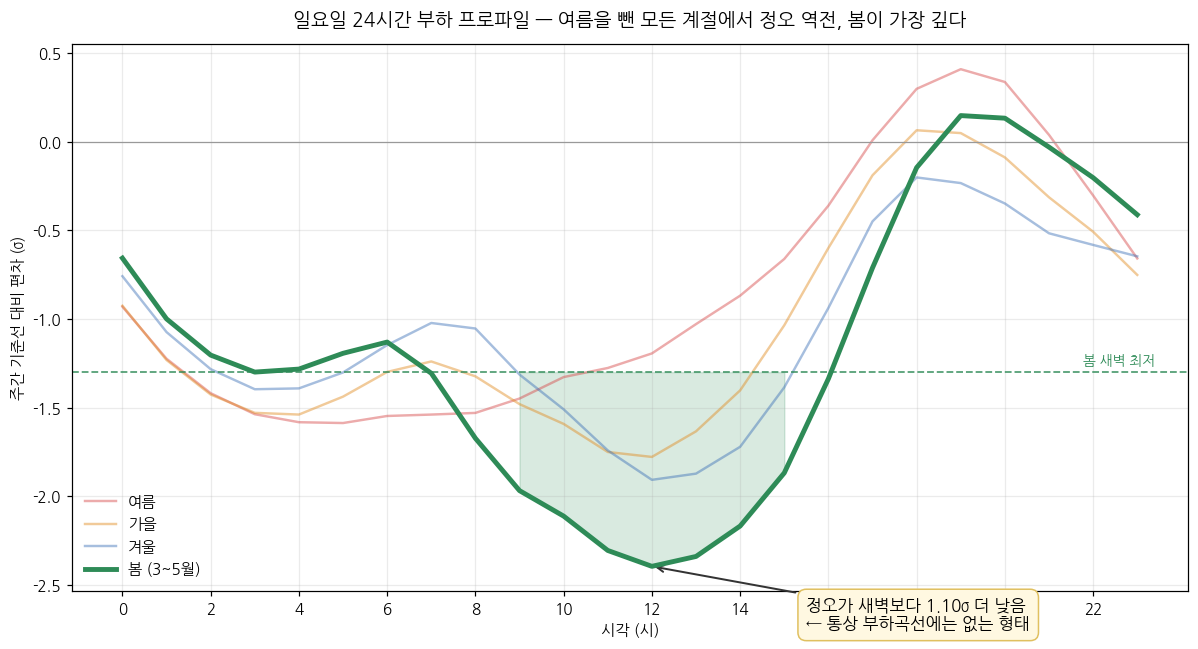

[MW 원단위] 정오 - 새벽최저
  봄: 정오  43,068MW  새벽최저  50,100MW  차이   -7,031MW
  여름: 정오  58,312MW  새벽최저  54,176MW  차이   +4,137MW
  가을: 정오  49,166MW  새벽최저  50,672MW  차이   -1,506MW
  겨울: 정오  53,246MW  새벽최저  57,125MW  차이   -3,879MW

봄 일요일 13일 중 11일에서 역전 확인
→ 미역전 2일(3/2, 3/16)의 원인은 미확인. 10/12와 같은 방식으로 검증 가능 [미확정]


In [14]:
색 = {'봄':'#2E8B57','여름':'#D64545','가을':'#E08A1E','겨울':'#3B6FB6'}

fig, ax = plt.subplots(figsize=(11,6))
for 계 in ['여름','가을','겨울']:                      # 비교군은 흐리게
    ax.plot(일_프.index, 일_프[계], color=색[계], lw=1.6, alpha=0.45, label=계)
ax.plot(일_프.index, 일_프['봄'], color=색['봄'], lw=3.2, label='봄 (3~5월)', zorder=5)

봄새벽 = 일_프['봄'].loc[0:6].min()   # 봄 곡선의 새벽 최저점
봄정오 = 일_프['봄'].loc[12]
ax.axhline(봄새벽, color=색['봄'], ls='--', lw=1.2, alpha=0.8)
ax.text(23.4, 봄새벽+0.04, '봄 새벽 최저', ha='right', fontsize=9, color=색['봄'])

구간 = 일_프.index[(일_프.index>=9)&(일_프.index<=15)]
ax.fill_between(구간, 일_프['봄'].loc[구간], 봄새벽,
                where=일_프['봄'].loc[구간] < 봄새벽, color=색['봄'], alpha=0.18)

ax.annotate(f'정오가 새벽보다 {봄새벽-봄정오:.2f}σ 더 낮음\n← 통상 부하곡선에는 없는 형태',
            xy=(12, 봄정오), xytext=(15.5, -2.75),
            arrowprops=dict(arrowstyle='->', color='#333', lw=1.3), fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', fc='#FFF8E1', ec='#E0C060'))

ax.axhline(0, color='#999', lw=0.8); ax.set_xticks(range(0,24,2))
ax.set_xlabel('시각 (시)'); ax.set_ylabel('주간 기준선 대비 편차 (σ)')
ax.set_title('일요일 24시간 부하 프로파일 — 여름을 뺀 모든 계절에서 정오 역전, 봄이 가장 깊다', fontsize=12.5, pad=12)
ax.legend(loc='lower left', frameon=False); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()
# MW 원단위로도 역전이 성립하는지 확인 — σ는 정규화된 값이라 반문이 가능하다
_계절들 = ['봄','여름','가을','겨울']   # 계절들 변수는 뒤 셀에서 정의되므로 여기선 따로 둔다
_p = 일요일.pivot_table(index='시', columns='계절', values='사용량', aggfunc='mean')[_계절들]
print('[MW 원단위] 정오 - 새벽최저')
for c in _계절들:
    _새벽 = _p[c].loc[0:6].min(); _정오 = _p[c].loc[12]
    print(f'  {c}: 정오 {_정오:>7,.0f}MW  새벽최저 {_새벽:>7,.0f}MW  차이 {_정오-_새벽:>+8,.0f}MW')

_봄 = 일요일[일요일['계절']=='봄']
_역전일 = sum(g[g['시']==12]['사용량'].iloc[0] < g[g['시']<=6]['사용량'].min()
             for _, g in _봄.groupby('날짜'))
print(f'\n봄 일요일 {_봄["날짜"].nunique()}일 중 {_역전일}일에서 역전 확인')
print('→ 미역전 2일(3/2, 3/16)의 원인은 미확인. 10/12와 같은 방식으로 검증 가능 [미확정]')


### 이 그래프를 읽는 법

정상적인 하루는 **새벽이 가장 낮고 낮이 높습니다.** 빨간선(여름)이 그 모양입니다.

그런데 초록선(봄)은 **정오가 새벽보다 더 아래로** 내려갑니다. 점선(자기 새벽 최저) 밑으로 파고든 음영 구간이 그것입니다.

낮 12시 수요가 새벽 3시보다 적다 — 자연스러운 수요 패턴으로는 나오지 않는 형태입니다. **낮에만 작동하면서 수요를 깎는 무언가**가 있다는 뜻입니다.

이 모양을 태양광 발전이 많은 계통에서 **오리 곡선(duck curve)** 이라고 부릅니다.

## 그런데 함정이 있다

여기서 바로 "태양광이다"라고 결론 내리면 안 됩니다. **평일도 확인해야 합니다.**

태양광은 요일을 가리지 않으므로 평일에도 흔적이 남아야 합니다. 그리고 만약 평일에서 다른 원인이 발견되면, 일요일 해석도 다시 봐야 합니다.

In [15]:
평_프 = 평일.pivot_table(index='시', columns='계절', values='z',
                        aggfunc='mean')[['봄','여름','가을','겨울']]
print(평_프.round(2).to_string())
print()
print('11시·12시·13시만 떼어 보면:')
print(평_프.loc[[11,12,13]].round(2).to_string())
print()
print('→ 평일에도 12시가 앞뒤보다 낮다. 얼핏 태양광 같지만…')

계절     봄    여름    가을    겨울
시                         
0  -0.15 -0.61 -0.48 -0.40
1  -0.47 -0.89 -0.78 -0.72
2  -0.64 -1.07 -0.95 -0.90
3  -0.71 -1.17 -1.03 -0.98
4  -0.65 -1.18 -0.99 -0.91
5  -0.41 -1.07 -0.76 -0.66
6   0.01 -0.74 -0.29 -0.13
7   0.47 -0.23  0.32  0.69
8   0.79  0.37  0.79  1.52
9   0.71  0.72  0.78  1.49
10  0.45  0.82  0.61  1.13
11  0.05  0.71  0.33  0.68
12 -0.37  0.52 -0.02  0.13
13  0.02  0.84  0.46  0.45
14  0.27  1.03  0.77  0.65
15  0.55  1.16  1.07  0.90
16  0.96  1.38  1.43  1.22
17  1.19  1.43  1.52  1.35
18  1.48  1.46  1.55  1.27
19  1.54  1.41  1.38  1.09
20  1.29  1.16  1.05  0.75
21  0.98  0.75  0.70  0.43
22  0.84  0.43  0.50  0.37
23  0.57  0.03  0.20  0.25

11시·12시·13시만 떼어 보면:
계절     봄    여름    가을    겨울
시                         
11  0.05  0.71  0.33  0.68
12 -0.37  0.52 -0.02  0.13
13  0.02  0.84  0.46  0.45

→ 평일에도 12시가 앞뒤보다 낮다. 얼핏 태양광 같지만…


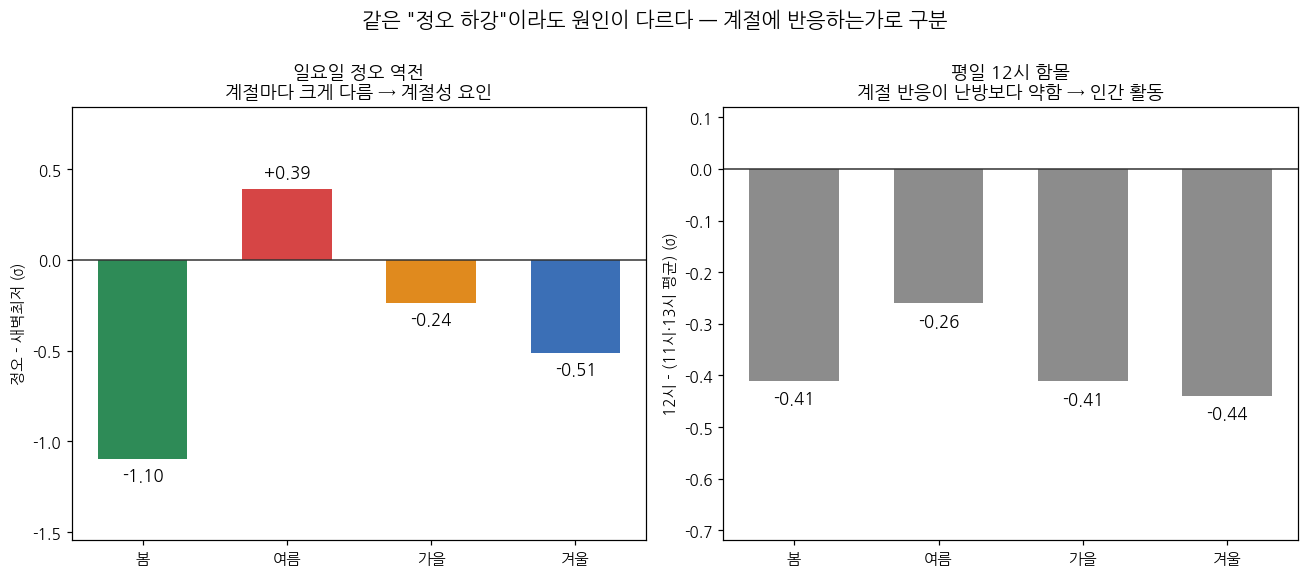

In [16]:
계절들 = ['봄','여름','가을','겨울']

# 지표1) 일요일 정오역전 = 정오z - 새벽최저z  (음수면 역전)
# 지표2) 평일 12시 함몰  = 12시z - (11시·13시 평균)
역전 = [일_프[c].loc[12] - 일_프[c].loc[0:6].min() for c in 계절들]
함몰 = [평_프[c].loc[12] - (평_프[c].loc[11]+평_프[c].loc[13])/2 for c in 계절들]

fig, axes = plt.subplots(1, 2, figsize=(12,5.2)); x = np.arange(4)

axes[0].bar(x, 역전, color=[색[c] for c in 계절들], width=0.62)
axes[0].axhline(0, color='#333', lw=1); axes[0].set_xticks(x); axes[0].set_xticklabels(계절들)
axes[0].set_ylabel('정오 - 새벽최저 (σ)')
axes[0].set_title('일요일 정오 역전\n계절마다 크게 다름 → 계절성 요인', fontsize=12)
for i,v in enumerate(역전): axes[0].text(i, v+(0.06 if v>=0 else -0.12), f'{v:+.2f}', ha='center', fontsize=11)
axes[0].set_ylim(min(역전)-0.45, max(역전)+0.45)

axes[1].bar(x, 함몰, color='#8C8C8C', width=0.62)
axes[1].axhline(0, color='#333', lw=1); axes[1].set_xticks(x); axes[1].set_xticklabels(계절들)
axes[1].set_ylabel('12시 - (11시·13시 평균) (σ)')
axes[1].set_title('평일 12시 함몰\n계절 반응이 난방보다 약함 → 인간 활동', fontsize=12)
for i,v in enumerate(함몰): axes[1].text(i, v-0.045, f'{v:+.2f}', ha='center', fontsize=11)
axes[1].set_ylim(min(함몰)-0.28, 0.12)

fig.suptitle('같은 "정오 하강"이라도 원인이 다르다 — 계절에 반응하는가로 구분', fontsize=13.5, y=1.0)
plt.tight_layout(); plt.show()

### 이 한 장이 분석의 결론이다

**왼쪽** — 일요일 정오역전은 계절 따라 부호까지 뒤집힙니다. 여름은 +, 봄은 -. 계절에 반응하는 요인입니다.

**오른쪽** — 평일 12시 함몰은 -0.26σ~-0.44σ로 겨울은 여름에 비해 1.69배입니다. 또한 평일 8시 난방의 경우 겨울은 여름에 비해 4.11배입니다. 계절 반응이 있지만 난방의 영향보다 작으므로 인간 활동입니다.

→ 평일의 12시 함몰은 인간 활동 중 점심시간으로 판별하고, **분석에서 배제**합니다.

## 겨울은 왜 역전되는가 — 난방을 배제하기

겨울도 정오역전이 있습니다(-0.51σ). 겨울 일사량은 낮은데 왜일까요? 평일 겨울 곡선에 답이 있습니다.

In [17]:
print('평일 아침 시간대 (난방 부하가 몰리는 구간)')
print(평_프.loc[[7,8,9,10,11,12]].round(2).to_string())
print()
print(f'겨울 8시 {평_프["겨울"].loc[8]:+.2f}σ vs 봄 8시 {평_프["봄"].loc[8]:+.2f}σ')
print(f'→ 겨울은 아침 피크가 봄과 가을 대비 대략 {평_프["겨울"].loc[8]/평_프["봄"].loc[8]:.1f}배.')
print('  난방이 아침에 몰리고 낮에는 완만해지는 프로파일이다.')
print(f'  다만 겨울 12시는 {평_프["겨울"].loc[12]:+.2f}σ로 봄 12시({평_프["봄"].loc[12]:+.2f}σ)보다 '
      f'{평_프["겨울"].loc[12]-평_프["봄"].loc[12]:+.2f}σ 높다 — 낮에 빠지는 것이 아니다.')
print('→ 즉 "정오가 새벽보다 낮다"는 현상은 태양광 없이 난방만으로도 만들어질 수 있다.')
print()
print('[비교] 난방 강도와 정오역전')
비교 = pd.DataFrame({
    '평일 8시 z (난방 강도)': [평_프[c].loc[8] for c in 계절들],
    '일요일 정오역전': 역전,
}, index=계절들).round(2)
print(비교.to_string())
print()
print(f'→ 난방이 가장 약한 봄({평_프["봄"].loc[8]:.2f})에서 역전이 가장 크다({역전[계절들.index("봄")]:.2f}).')
print('   난방으로 설명되지 않는 잔여분이 봄에 크게 남는다. 이 잔여분의 후보가 태양광이다.')


평일 아침 시간대 (난방 부하가 몰리는 구간)
계절     봄    여름    가을    겨울
시                         
7   0.47 -0.23  0.32  0.69
8   0.79  0.37  0.79  1.52
9   0.71  0.72  0.78  1.49
10  0.45  0.82  0.61  1.13
11  0.05  0.71  0.33  0.68
12 -0.37  0.52 -0.02  0.13

겨울 8시 +1.52σ vs 봄 8시 +0.79σ
→ 겨울은 아침 피크가 봄과 가을 대비 대략 1.9배.
  난방이 아침에 몰리고 낮에는 완만해지는 프로파일이다.
  다만 겨울 12시는 +0.13σ로 봄 12시(-0.37σ)보다 +0.50σ 높다 — 낮에 빠지는 것이 아니다.
→ 즉 "정오가 새벽보다 낮다"는 현상은 태양광 없이 난방만으로도 만들어질 수 있다.

[비교] 난방 강도와 정오역전
    평일 8시 z (난방 강도)  일요일 정오역전
봄              0.79     -1.10
여름             0.37      0.39
가을             0.79     -0.24
겨울             1.52     -0.51

→ 난방이 가장 약한 봄(0.79)에서 역전이 가장 크다(-1.10).
   난방으로 설명되지 않는 잔여분이 봄에 크게 남는다. 이 잔여분의 후보가 태양광이다.


---
# 7장 · 남은 이상치와 결론

## 검증 가능한 예측 하나

일요일별로 펼쳐보면 얕은 날이 몇 개 보입니다. 그런데 **성격이 다릅니다.**

9월(9/7 -0.62, 9/28 -0.70)은 잔여 냉방부하가 남아 있는 **계절 전이 구간**이라 전반적으로 얕고 변동이 큽니다. 이건 설명이 됩니다.

문제는 **10월 12일(-0.49)** 입니다. 같은 달 앞뒤 일요일이 -1.81(10/19), -1.94(10/26)인데 혼자 세 배 넘게 얕습니다. **계절 추세로 설명되지 않는 국소적 예외**입니다.

태양광이 원인이라면 이날은 **흐렸어야** 합니다. 구름이 끼면 잠식이 줄고 곡선이 얕아지니까요.

이것은 막연한 추가 확인이 아니라 **가설이 만들어낸 구체적 예측**이고, 기상 데이터로 맞고 틀림을 판정할 수 있습니다.

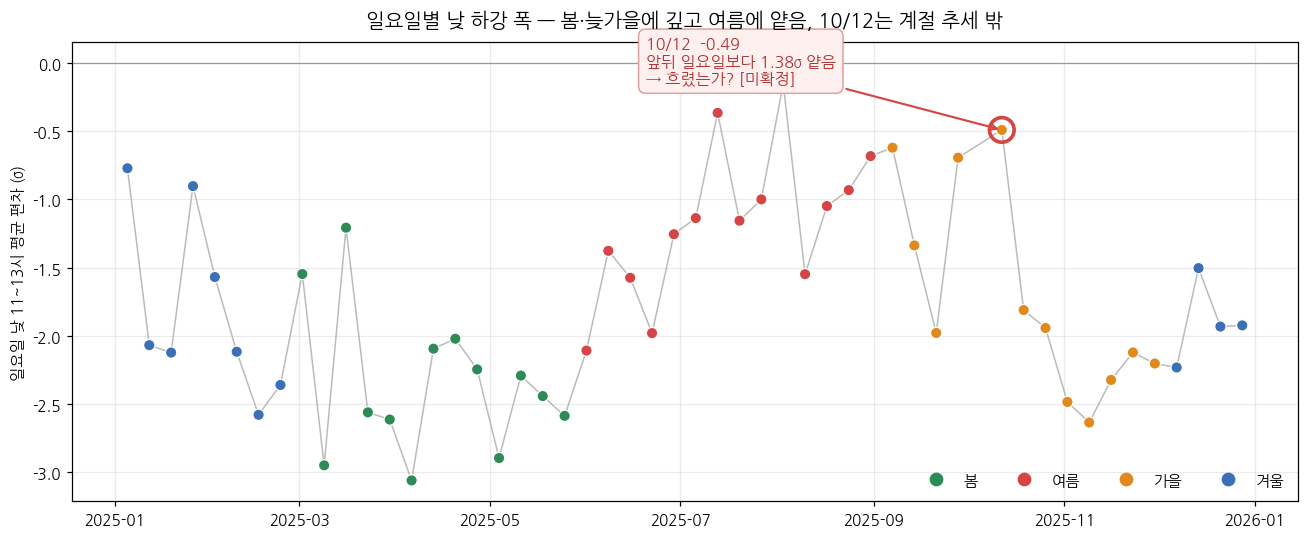

가을 일요일 낮 편차
날짜
2025-09-07   -0.62
2025-09-14   -1.34
2025-09-21   -1.98
2025-09-28   -0.70
2025-10-12   -0.49
2025-10-19   -1.81
2025-10-26   -1.94
2025-11-02   -2.48
2025-11-09   -2.63
2025-11-16   -2.32
2025-11-23   -2.12
2025-11-30   -2.20


In [18]:
요일이름 = {0:'월',1:'화',2:'수',3:'목',4:'금',5:'토',6:'일'}
낮z = 일요일[일요일['시'].between(11,13)].groupby('날짜')['z'].mean().sort_index()
날짜idx = pd.to_datetime(낮z.index)
계절색 = [색[계절맵[dt.month]] for dt in 날짜idx]

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(날짜idx, 낮z.values, color='#BBB', lw=1, zorder=1)
ax.scatter(날짜idx, 낮z.values, c=계절색, s=55, zorder=3, edgecolor='white', lw=0.8)

타깃 = pd.Timestamp('2025-10-12')
if 타깃.date() in set(낮z.index):
    v = 낮z.loc[타깃.date()]
    ax.scatter([타깃],[v], s=260, facecolor='none', edgecolor='#D64545', lw=2.4, zorder=4)
    _앞뒤 = 낮z.loc[[pd.Timestamp('2025-10-19').date(), pd.Timestamp('2025-10-26').date()]].mean()
    ax.annotate(f'10/12  {v:.2f}\n앞뒤 일요일보다 {v-_앞뒤:.2f}σ 얕음\n→ 흐렸는가? [미확정]',
                xy=(타깃, v), xytext=(pd.Timestamp('2025-06-20'), -0.15),
                arrowprops=dict(arrowstyle='->', color='#D64545', lw=1.4),
                fontsize=10.5, color='#B03030',
                bbox=dict(boxstyle='round,pad=0.45', fc='#FFF0F0', ec='#E0A0A0'))

ax.axhline(0, color='#999', lw=0.8)
ax.set_ylabel('일요일 낮 11~13시 평균 편차 (σ)')
ax.set_title('일요일별 낮 하강 폭 — 봄·늦가을에 깊고 여름에 얕음, 10/12는 계절 추세 밖', fontsize=13, pad=10)
ax.grid(alpha=0.25)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0], marker='o', ls='', color=색[c], label=c, markersize=8)
                   for c in 계절들], loc='lower right', frameon=False, ncol=4)
plt.tight_layout(); plt.show()

print('가을 일요일 낮 편차')
가을 = 낮z[[dt.month in (9,10,11) for dt in 날짜idx]]
print(가을.round(2).to_string())

## 검증 — 그날 흐렸는가

앞 그래프는 10/12를 **검증 가능한 예측**으로 남겼다. 태양광이 원인이라면 그날은 흐렸어야 한다.
기상청 ASOS 일자료(2025년 전 기간, 97개 지점)를 붙여 확인한다.

- 셀 1 — 사례 판정: 역전이 없던 날이 실제로 흐렸는가
- 셀 2 — 전수 확인: 51일 전체에서 관계가 성립하는가, 달 단위 요인 때문은 아닌가

두 셀은 짝이다. 사례만 보면 "맞는 것만 골랐다"는 반박을 못 막는다.

In [19]:
# ─────────────────────────────────────────────────────────────
# 그날 흐렸는가 — 기상 데이터를 붙인다
# 앞 셀의 일요일·낮z·공휴일·계절맵을 그대로 쓴다. 다시 정의하지 않는다.
# ─────────────────────────────────────────────────────────────
ASOS = '/content/drive/MyDrive/ASOS_2025_일자료.csv'
기상 = pd.read_csv(ASOS, encoding='cp949')

# ① 열을 위치가 아니라 이름으로 찾는다.
#    기상청은 요소를 추가하면 열 순서를 바꾼다(기온을 넣으면 앞으로 온다).
#    위치로 잡으면 기온이 '일조'라는 이름으로 들어가고, 에러 없이 상관계수만 틀린다.
def 열찾기(키워드):
    후보 = [c for c in 기상.columns if 키워드 in c]
    if not 후보:
        raise KeyError(f"'{키워드}'가 든 열이 없습니다 → 다운로드 요소를 확인하세요")
    return 후보[0]

일조열, 일사열 = 열찾기('일조시간'), 열찾기('일사량')
기상['일시'] = pd.to_datetime(기상['일시']).dt.date

# ② 파일이 맞는지 먼저 본다. 기간이 짧은 파일이 올라와도 에러가 안 나기 때문.
print('【기상 파일 확인】')
print(f'  행 {len(기상):,} · 지점 {기상["지점명"].nunique()}개 · '
      f'{min(기상["일시"])} ~ {max(기상["일시"])}')
print(f'  결측 — 일조 {기상[일조열].isna().sum()}건 / 일사 {기상[일사열].isna().sum()}건')
print( '  → 일사는 관측 지점이 적다. 판단 근거는 일조로 둔다.')

# ③ 지점을 평균해 "그날 전국이 얼마나 맑았나"를 하루 한 값으로 만든다
전국 = 기상.groupby('일시')[[일조열, 일사열]].mean()
전국.columns = ['일조', '일사']

# ④ 일요일별 역전 폭(MW) — 13일 중 11일을 셀 때 쓴 것과 같은 정의
#    ※ 계절 평균 역전(봄 -7,031MW 등)은 '평균 곡선'의 새벽최저를 쓴다. 정의가 다르므로
#      여기서 나온 값을 그 자리에 옮겨 쓰지 말 것.
정오     = 일요일[일요일['시']==12].set_index('날짜')['사용량']
새벽최저 = 일요일[일요일['시']<=6].groupby('날짜')['사용량'].min()

일 = pd.DataFrame({'낮z': 낮z, '역전MW': 정오 - 새벽최저}).join(전국, how='inner')
일['계절'] = [계절맵[dt.month] for dt in pd.to_datetime(일.index)]
print(f'\n병합된 일요일 {len(일)}일 (공휴일 {len(공휴일)}일 제외) · 역전 발생 {(일["역전MW"]<0).sum()}일')

# ⑤ 역전이 없던 날이 실제로 흐렸는가 — 2025년 전체에서 몇 등이었는지로 본다
예외3일 = {}   # 결론 셀에서 다시 쓰므로 값을 보관한다
print('\n【역전이 없던 날의 기상】')
for 날 in ['2025-10-12', '2025-03-02', '2025-03-16']:
    t = pd.Timestamp(날).date()
    예외3일[날] = (전국.loc[t,'일조'], (전국['일조'] < 전국.loc[t,'일조']).mean()*100)
    print(f'  {날}  일조 {예외3일[날][0]:5.2f}hr  '
          f'(2025년 {예외3일[날][1]:4.1f}백분위)  역전 {일.loc[t,"역전MW"]:+7,.0f}MW')

# ⑥ 10월 세 일요일 — 같은 달이라 계절 조건이 거의 같다
print('\n【10월 일요일 3주 — 계절 조건이 같은 구간】')
시월 = 일[[dt.month == 10 for dt in pd.to_datetime(일.index)]]
print(시월[['일조', '역전MW', '낮z']].round(2).to_string())
print('  → 일조가 낮은 순서와 역전이 얕은 순서가 일치하는가')

【기상 파일 확인】
  행 35,385 · 지점 97개 · 2025-01-01 ~ 2025-12-31
  결측 — 일조 167건 / 일사 12082건
  → 일사는 관측 지점이 적다. 판단 근거는 일조로 둔다.

병합된 일요일 51일 (공휴일 19일 제외) · 역전 발생 32일

【역전이 없던 날의 기상】
  2025-10-12  일조  1.78hr  (2025년 14.5백분위)  역전  +5,584MW
  2025-03-02  일조  0.64hr  (2025년  6.0백분위)  역전     +17MW
  2025-03-16  일조  2.46hr  (2025년 19.2백분위)  역전  +3,000MW

【10월 일요일 3주 — 계절 조건이 같은 구간】
              일조    역전MW    낮z
2025-10-12  1.78  5584.0 -0.49
2025-10-19  2.22  -473.0 -1.81
2025-10-26  3.13 -2994.0 -1.94
  → 일조가 낮은 순서와 역전이 얕은 순서가 일치하는가


In [20]:
# ─────────────────────────────────────────────────────────────
# 우연이 아닌가 — 51일 전체로 확인한다
# 사례 3건은 "맞는 것만 골랐다"는 반문을 못 막는다. 전수로 본다.
# ─────────────────────────────────────────────────────────────
# ① 월 내 편차 — 계절 요인을 상수로 만든다
#    같은 달 안에서는 냉난방 수준이 거의 같다. 각 달의 평균을 빼면
#    달끼리의 차이가 사라지고 "그 달 안에서 맑았나/깊었나"만 남는다.
#    transform('mean')은 mean()과 달리 원래 행 수를 유지하며 그룹 평균을 채워 넣는다.
일['월'] = [dt.month for dt in pd.to_datetime(일.index)]
일['일조_편차']   = 일['일조']   - 일.groupby('월')['일조'].transform('mean')
일['역전_편차'] = 일['역전MW'] - 일.groupby('월')['역전MW'].transform('mean')

# ② 계절별로 원값 상관과 통제 후 상관을 나란히 본다
#    볼 것은 "얼마나 큰가"가 아니라 "계절을 지워도 얼마나 안 변했나"이다.
표 = []
for c in 계절들:
    s = 일[일['계절'] == c]
    r_원 = s['일조'].corr(s['역전MW'])
    r_통 = s['일조_편차'].corr(s['역전_편차'])
    표.append({'계절': c, 'n': len(s), '단순 r': round(r_원, 3),
               '월내편차 r': round(r_통, 3), 'r²': round(r_통**2, 3)})
r전체_원 = 일['일조'].corr(일['역전MW'])
r전체_통 = 일['일조_편차'].corr(일['역전_편차'])
표.append({'계절': '전체', 'n': len(일), '단순 r': round(r전체_원, 3),
           '월내편차 r': round(r전체_통, 3), 'r²': round(r전체_통**2, 3)})

print('【일조시간 ↔ 역전 폭】  음수 = 맑을수록 깊다')
print(pd.DataFrame(표).to_string(index=False))
print('  r² = 역전 폭의 흩어짐 중 일조로 설명되는 비율')
_r  = {행['계절']: 행['단순 r']     for 행 in 표}   # 결론 셀에서 f-string으로 꺼내 쓴다
_rc = {행['계절']: 행['월내편차 r'] for 행 in 표}

# ③ 우연히 이 정도가 나올 수 있는가 — 짝을 무작위로 섞어 세어 본다
#    정규분포를 가정하지 않는다. 이 데이터의 잔차는 정규분포가 아니다.
rng = np.random.default_rng(0)
관측 = abs(r전체_통)
섞은r = [abs(pd.Series(rng.permutation(일['역전_편차'].values)).corr(
              pd.Series(일['일조_편차'].values))) for _ in range(5000)]
초과 = sum(v >= 관측 for v in 섞은r)
print(f'\n【순열검정】 짝을 5,000번 무작위로 섞었을 때 |r| ≥ {관측:.3f} 인 경우: {초과}건')

# ④ 이상치가 만든 상관인가 — 역전이 없던 날을 빼고 다시 본다
봄 = 일[일['계절'] == '봄']
봄_역전만 = 봄[봄['역전MW'] < 0]
print(f'\n【이상치 의존 확인】 봄 {len(봄)}일 r={봄["일조"].corr(봄["역전MW"]):+.3f}  →  '
      f'미역전 2일 제외 {len(봄_역전만)}일 r={봄_역전만["일조"].corr(봄_역전만["역전MW"]):+.3f}')

【일조시간 ↔ 역전 폭】  음수 = 맑을수록 깊다
계절  n   단순 r  월내편차 r    r²
 봄 13 -0.920  -0.915 0.837
여름 14 -0.626  -0.674 0.454
가을 12 -0.881  -0.871 0.759
겨울 12 -0.942  -0.920 0.846
전체 51 -0.553  -0.822 0.675
  r² = 역전 폭의 흩어짐 중 일조로 설명되는 비율

【순열검정】 짝을 5,000번 무작위로 섞었을 때 |r| ≥ 0.822 인 경우: 0건

【이상치 의존 확인】 봄 13일 r=-0.920  →  미역전 2일 제외 11일 r=-0.894


In [21]:
# 어디까지가 확인이고 어디부터가 추정인지 코드에 남긴다.
# 시간이 지나 이 노트북만 다시 봐도 경계가 보여야 한다.
_봄일 = 일[일['계절']=='봄']

print('【확인된 사실】')
print(f'  · 일요일 낮 하강 최대 {낮.min():.2f}σ({낮.idxmin()}월) ~ 최소 {낮.max():.2f}σ({낮.idxmax()}월)')
print(f'  · 같은 날 밤(20~22시) 편차 {밤.min():+.2f} ~ {밤.max():+.2f}σ → 밤에는 하강이 없다')
print( '  · 창 설정(19~21 vs 20~22)을 바꿔도 상위 6개월 순위는 완전히 일치한다')
print( '  · 다만 하위 6개월과 σ↔MW 단위 변경에서는 순위가 바뀐다 — 방향(부호)만 12개월 일치')
print( '  · 평일 12시 함몰은 계절 반응이 난방보다 약함 → 인간 활동으로 판별, 분석에서 배제')
print(f'  · 예외로 두었던 3일 중 이틀인 3/2와 3/16에 봄 일요일 {len(_봄일)}일 중에 역전이 없었고,')
print( '    나머지 하루인 10/12에 가을 일요일 중 계절 추세로 설명되지 않게 얕았다.')
print(f'    이때 3/2의 경우 일조시간이 {예외3일["2025-03-02"][0]:.2f}시간으로 '
      f'1년 중 하위 {예외3일["2025-03-02"][1]:.0f}%이다.')
print(f'  · 일년의 52일 일요일 중 공휴일을 뺀 {len(일)}일에서 맑을수록 역전이 깊다.')
print(f'    봄의 경우 단순 r이 {_r["봄"]:.3f}, 가을의 경우 {_r["가을"]:.3f}, 겨울의 경우 {_r["겨울"]:.3f}이다.')
print(f'    여름의 경우 {_r["여름"]:.3f}이다. 여름도 같은 방향이지만 다른 계절보다 관계가 약하다.')
print( '    따라서 여름은 기존에 측정 불가 구간으로 판정한 것과 어긋나지 않는다.')
print( '  · 각 달의 평균을 빼고 비교했다. 그 결과 계절별 값이 거의 그대로이다.')
print( '    그러므로 달 단위로 변하는 요인이 만든 관계가 아니다.')

print('\n【판별로 제외한 것】')
print( '  · 점심시간  — 계절 반응이 난방보다 약하므로 계절성 현상의 원인으로 보기 어렵다')
print( '  · 겨울 역전 — 난방이 아침에 몰리는 프로파일로도 설명 가능하다')
print( '  · 연휴      — 조업 중단 요인이므로 사전 제외했다')

print('\n【추정 — 확인되지 않음】')
print( '  · 난방이 가장 약한 봄에 역전이 가장 크다 → 잔여분을 태양광 잠식으로 추정')
print( '  · 근거는 배제법이며, 기상 자료와는 대조했으나 발전실적과는 대조하지 못했다')

print('\n【한계】')
print( '  · 상별 전류·무효전력이 없어 설비 단위 원인 규명은 불가능하다')
print( '  · 2025년 1개 연도 — "매년 반복되는 현상"이라 말할 근거는 없다')
print(f'  · 설비 용량으로 가중하지 않았기에 현재의 상태는 전국 {기상["지점명"].nunique()}개 지점에서의')
print( '    단순 평균이다. 그래서 일조시간이 실제 발전 조건을 얼마나 대표하는지 알 수 없다')

print('\n【다음에 확인할 것】')
print( '  · 전력거래소 태양광 발전실적 — 잔여분과 실제 발전량이 맞는지')


【확인된 사실】
  · 일요일 낮 하강 최대 -2.49σ(5월) ~ 최소 -0.92σ(8월)
  · 같은 날 밤(20~22시) 편차 -0.54 ~ +0.11σ → 밤에는 하강이 없다
  · 창 설정(19~21 vs 20~22)을 바꿔도 상위 6개월 순위는 완전히 일치한다
  · 다만 하위 6개월과 σ↔MW 단위 변경에서는 순위가 바뀐다 — 방향(부호)만 12개월 일치
  · 평일 12시 함몰은 계절 반응이 난방보다 약함 → 인간 활동으로 판별, 분석에서 배제
  · 예외로 두었던 3일 중 이틀인 3/2와 3/16에 봄 일요일 13일 중에 역전이 없었고,
    나머지 하루인 10/12에 가을 일요일 중 계절 추세로 설명되지 않게 얕았다.
    이때 3/2의 경우 일조시간이 0.64시간으로 1년 중 하위 6%이다.
  · 일년의 52일 일요일 중 공휴일을 뺀 51일에서 맑을수록 역전이 깊다.
    봄의 경우 단순 r이 -0.920, 가을의 경우 -0.881, 겨울의 경우 -0.942이다.
    여름의 경우 -0.626이다. 여름도 같은 방향이지만 다른 계절보다 관계가 약하다.
    따라서 여름은 기존에 측정 불가 구간으로 판정한 것과 어긋나지 않는다.
  · 각 달의 평균을 빼고 비교했다. 그 결과 계절별 값이 거의 그대로이다.
    그러므로 달 단위로 변하는 요인이 만든 관계가 아니다.

【판별로 제외한 것】
  · 점심시간  — 계절 반응이 난방보다 약하므로 계절성 현상의 원인으로 보기 어렵다
  · 겨울 역전 — 난방이 아침에 몰리는 프로파일로도 설명 가능하다
  · 연휴      — 조업 중단 요인이므로 사전 제외했다

【추정 — 확인되지 않음】
  · 난방이 가장 약한 봄에 역전이 가장 크다 → 잔여분을 태양광 잠식으로 추정
  · 근거는 배제법이며, 기상 자료와는 대조했으나 발전실적과는 대조하지 못했다

【한계】
  · 상별 전류·무효전력이 없어 설비 단위 원인 규명은 불가능하다
  · 2025년 1개 연도 — "매년 반복되는 현상"이라 말할

---
# 부록 · 이 분석에서 판단이 바뀐 지점

분석은 처음 세운 가설대로 흘러가지 않았습니다. **세 번 방향을 바꿨습니다.**

| 단계 | 처음 생각 | 데이터가 말한 것 | 바뀐 결론 |
|---|---|---|---|
| 4장 | 설비 이상을 찾는다 | 걸린 게 전부 일요일 낮 | 이상탐지의 핵심은 탐지가 아니라 **판별** |
| 6장 | 정오 역전 = 태양광 | 평일 12시 함몰은 계절 무관 / 겨울 역전은 난방으로 설명됨 | 태양광은 **잔여분에 대한 추정**까지만 |
| 6장 | 겨울이 가장 깊으니 태양광이 아니다 | 세 시각이 같이 내려가면 앞뒤차이가 0에 가까워진다 | 이 지표로는 태양광을 판정할 수 없다 |

두 번째가 특히 중요합니다. 시간별 곡선 하나만 보고 "오리 곡선이니 태양광"으로 결론냈다면 틀린 분석이 됐을 것입니다. **평일이라는 대조군을 확인한 것**이 오류를 막았습니다.

## 이 노트북에서 쓴 판다스 문법 정리

| 문법 | 하는 일 |
|---|---|
| `pd.read_csv(..., encoding='cp949')` | 한국 공공데이터 읽기 |
| `.dropna(how='all')` | 전부 빈 행 제거 |
| `.melt(id_vars, value_vars)` | 가로형 → 세로형 |
| `.rolling(n, center=True).mean()` | 이동평균 |
| `.dt.month / .dt.hour / .dt.dayofweek` | 시간에서 정보 추출 |
| `.diff()` | 앞 값과의 차이 (첫 값은 NaT/NaN) |
| `.cumsum()` | 누적합 — 연속 구간 묶기에 사용 |
| `.groupby(...).agg(...)` | 묶어서 집계 |
| `.pivot_table(index, columns, values)` | 표 재구성 |
| `.isin([...])` | 목록에 포함되는가 |
| `~` | not (조건 뒤집기) |

---

## 부록 · 서류 수치 검증

기술서 문장에 들어간 수치를 전부 이 셀에서 재계산한다.
서사가 아니라 대조표이므로 본문이 아닌 부록에 둔다.

**기준선이 다른 값을 나누지 않는다.** 점심 함몰과 난방 강도는 둘 다
`대상 시각 − (양옆 두 시각 평균)`으로 축을 맞춘 뒤에 비교한다.

In [22]:
# ─────────────────────────────────────────────────────────────
# 부록 · 서류에 쓴 수치가 어느 계산에서 나왔는가
# 기술서 문장에 들어간 값을 여기서 전부 재계산한다.
# 기억이나 메모가 아니라 이 셀의 출력이 근거다.
# ─────────────────────────────────────────────────────────────
# MW 원단위 피벗 — 기존 평_프·일_프는 σ 단위다. values만 바꾼다.
# σ는 "통계 처리 결과 아니냐"는 반문이 가능하지만, MW에는 그 반문이 안 통한다.
평_MW = 평일.pivot_table(index='시', columns='계절', values='사용량', aggfunc='mean')[계절들]
일_MW = 일요일.pivot_table(index='시', columns='계절', values='사용량', aggfunc='mean')[계절들]

def 앞뒤대비(표, 시각):
    """그 시각이 양옆 두 시각의 평균보다 얼마나 낮은가(MW). 음수면 파임."""
    return {c: 표[c].loc[시각] - (표[c].loc[시각-1] + 표[c].loc[시각+1])/2 for c in 계절들}

점심 = 앞뒤대비(평_MW, 12)    # 평일 12시 − (11시·13시 평균)
난방 = 앞뒤대비(평_MW,  8)    # 평일  8시 − ( 7시· 9시 평균)   ← 점심과 같은 구조
일정오 = 앞뒤대비(일_MW, 12)  # 일요일 12시 − (11시·13시 평균)

print('【같은 축(앞뒤 대비)으로 통일해 비교한다】 단위 MW')
print(pd.DataFrame({'평일 점심(12시)': 점심, '평일 난방(8시)': 난방,
                    '일요일 정오(12시)': 일정오}).round(0).to_string())
print(f'\n  계절 반응  점심 {점심["겨울"]/점심["여름"]:.2f}배  vs  난방 {난방["겨울"]/난방["여름"]:.2f}배')
print( '  → 점심도 계절을 타지만 난방의 절반 수준. 인간 활동 범주로 판별')
print(f'  일요일 정오는 앞뒤 대비 {일정오["봄"]:+,.0f}MW — 앞뒤로는 거의 파이지 않는다')

# 같은 시각을 두 기준으로 재면 값이 32배 차이 난다 → 지표가 무엇을 재는지의 문제
봄_기준선대비 = 일요일[(일요일['계절']=='봄') & (일요일['시']==12)]['편차'].mean()
print(f'\n【같은 시각, 다른 기준선 — 12시 지표가 태양광을 못 잡는 이유】')
print(f'  봄 일요일 정오  168시간 기준선 대비 {봄_기준선대비:+,.0f}MW')
print(f'                  앞뒤(11·13시) 대비 {일정오["봄"]:+,.0f}MW')
print( '  → 태양광은 11시·13시에도 작동한다. 세 시각이 함께 내려가면 앞뒤 차이는 0에 수렴한다.')

# 2.5σ 34건의 내역 — "하강만 골라 본 것 아니냐"에 답하려면 상승도 세야 한다
하강 = 이상[이상['z'] < 0]; 상승 = 이상[이상['z'] > 0]
print(f'\n【2.5σ 탐지 {len(이상)}건의 방향】 하강 {len(하강)}건 / 상승 {len(상승)}건')
if len(상승):
    for _, r in 상승.iterrows():
        print(f'  상승: {r["시각"]:%Y-%m-%d(%a) %H시}  {r["z"]:+.2f}σ  {r["사용량"]:,.0f}MW')
print( '  → abs(z)로 잡았으므로 상승도 걸릴 수 있었다. 실제로 1건뿐인 것 자체가 결과다.')

# 봄 일요일 정오·새벽최저 — 확정 수치의 정의를 코드로 고정한다
봄_정오 = 일_MW['봄'].loc[12]; 봄_새벽 = 일_MW['봄'].loc[0:6].min()
print(f'\n【봄 일요일 (평균 곡선 기준)】 정오 {봄_정오:,.0f}MW  <  새벽최저 {봄_새벽:,.0f}MW '
      f'({봄_정오-봄_새벽:+,.0f}MW)')
print( '  ※ 새벽최저 = 시간대별 평균 곡선의 0~6시 최솟값.')
print( '     일별 최솟값의 평균(앞 셀의 역전MW)과 정의가 다르다 — 서로 옮겨 쓰지 말 것.')

【같은 축(앞뒤 대비)으로 통일해 비교한다】 단위 MW
    평일 점심(12시)  평일 난방(8시)  일요일 정오(12시)
봄      -2699.0     1317.0       -485.0
여름     -2406.0     1192.0       -377.0
가을     -3022.0     1780.0       -619.0
겨울     -3417.0     3348.0       -794.0

  계절 반응  점심 1.42배  vs  난방 2.81배
  → 점심도 계절을 타지만 난방의 절반 수준. 인간 활동 범주로 판별
  일요일 정오는 앞뒤 대비 -485MW — 앞뒤로는 거의 파이지 않는다

【같은 시각, 다른 기준선 — 12시 지표가 태양광을 못 잡는 이유】
  봄 일요일 정오  168시간 기준선 대비 -15,728MW
                  앞뒤(11·13시) 대비 -485MW
  → 태양광은 11시·13시에도 작동한다. 세 시각이 함께 내려가면 앞뒤 차이는 0에 수렴한다.

【2.5σ 탐지 34건의 방향】 하강 33건 / 상승 1건
  상승: 2025-03-04(Tue) 10시  +2.62σ  85,127MW
  → abs(z)로 잡았으므로 상승도 걸릴 수 있었다. 실제로 1건뿐인 것 자체가 결과다.

【봄 일요일 (평균 곡선 기준)】 정오 43,068MW  <  새벽최저 50,100MW (-7,031MW)
  ※ 새벽최저 = 시간대별 평균 곡선의 0~6시 최솟값.
     일별 최솟값의 평균(앞 셀의 역전MW)과 정의가 다르다 — 서로 옮겨 쓰지 말 것.
